In [2]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os

dataset_path = "/content/drive/MyDrive/PavBhaji_Project/dataset"

print(os.listdir(dataset_path))

['pavbhaji.json', '.DS_Store', 'images']


In [4]:
import os

images_path = dataset_path + "/images"

print(os.listdir(images_path))

['1', '0', '.DS_Store']


In [5]:
print("Class 0 images:", len(os.listdir(images_path + "/0")))
print("Class 1 images:", len(os.listdir(images_path + "/1")))

Class 0 images: 269
Class 1 images: 183


In [6]:
import pandas as pd

json_path = dataset_path + "/pavbhaji.json"

df = pd.read_json(json_path)

print("Number of posts:", len(df))
print("Number of columns:", len(df.columns))
print("\nColumns:")
print(df.columns.tolist())

Number of posts: 1500
Number of columns: 18

Columns:
['dimensions', 'display_url', 'edge_liked_by', 'edge_media_preview_like', 'edge_media_to_caption', 'edge_media_to_comment', 'id', 'is_video', 'location', 'owner', 'shortcode', 'tags', 'taken_at_timestamp', 'thumbnail_resources', 'thumbnail_src', 'urls', 'video_view_count', 'comments_disabled']


In [7]:
print("First caption:")
print(df["edge_media_to_caption"].iloc[0])

print("\nFirst tags:")
print(df["tags"].iloc[0])

First caption:
{'edges': [{'node': {'text': 'TAG A PAV BHAJI FANATIC 😋😍 PC @exploringplates For more food updates follow @ekplate To get featured tag us on your pictures ❤ .\n.\n#ekplate #nomnom #nom #delhi_igers #eeeeeats #foodaholic #foodblogger #foodphotography #foodcoma #foodgram #things2doinmumbai #foodblog #foodgasm #foodlove #india  #foodie #yummy  #bombay #mumbai #delhi #pune  #bangalore #streetfood  #ekplatepavbhaji #butter #vadapav #pavbhaji #mumbaifood'}}]}

First tags:
['vadapav', 'foodgram', 'foodphotography', 'foodblogger', 'mumbai', 'foodaholic', 'foodie', 'foodcoma', 'ekplate', 'foodlove', 'things2doinmumbai', 'foodblog', 'nomnom', 'pune', 'india', 'butter', 'yummy', 'nom', 'eeeeeats', 'ekplatepavbhaji', 'mumbaifood', 'bombay', 'streetfood', 'pavbhaji', 'bangalore', 'delhi', 'delhi_igers', 'foodgasm']


In [8]:
def extract_caption(row):
    caption_data = row["edge_media_to_caption"]

    if isinstance(caption_data, dict):
        edges = caption_data.get("edges", [])

        if edges:
            return edges[0].get("node", {}).get("text", "")

    return ""


def extract_tags(row):
    tags = row["tags"]

    if isinstance(tags, list):
        return " ".join(tags)

    return ""


df["caption_text"] = df.apply(extract_caption, axis=1)
df["tags_text"] = df.apply(extract_tags, axis=1)

df["combined_text"] = (
    df["caption_text"] + " " + df["tags_text"]
).str.lower().str.strip()


print(df[["caption_text", "tags_text", "combined_text"]].head(3))

                                        caption_text  \
0  TAG A PAV BHAJI FANATIC 😋😍 PC @exploringplates...   
1  देसी स्टाइल पाव भाजी/Desi Style Paav Bhaji 🇮🇳 ...   
2  Pav Bhaji😍😍😋\n.\nFollow @street_food_chandigar...   

                                           tags_text  \
0  vadapav foodgram foodphotography foodblogger m...   
1  healthyfood sokolkata mumbaifoodie faridabad i...   
2  foodphotography mumbaipeople vascom delhiboy p...   

                                       combined_text  
0  tag a pav bhaji fanatic 😋😍 pc @exploringplates...  
1  देसी स्टाइल पाव भाजी/desi style paav bhaji 🇮🇳 ...  
2  pav bhaji😍😍😋\n.\nfollow @street_food_chandigar...  


In [9]:
print("Total posts:", len(df))

print("Empty captions:",
      (df["caption_text"].str.strip() == "").sum())

print("Empty tags:",
      (df["tags_text"].str.strip() == "").sum())

print("Empty combined text:",
      (df["combined_text"].str.strip() == "").sum())

Total posts: 1500
Empty captions: 1
Empty tags: 18
Empty combined text: 1


In [10]:
print("\nAverage caption length:",
      df["caption_text"].str.len().mean())

print("Average combined text length:",
      df["combined_text"].str.len().mean())


Average caption length: 420.92
Average combined text length: 625.9326666666667


In [11]:
import os

folder_0 = images_path + "/0"
folder_1 = images_path + "/1"

images_0 = [
    os.path.splitext(f)[0]
    for f in os.listdir(folder_0)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

images_1 = [
    os.path.splitext(f)[0]
    for f in os.listdir(folder_1)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

print("Class 0 images:", len(images_0))
print("Class 1 images:", len(images_1))

Class 0 images: 269
Class 1 images: 183


In [12]:
def find_label(row):
    display_url = str(row.get("display_url", ""))
    shortcode = str(row.get("shortcode", ""))

    # Check Pav-Bhaji images
    for img in images_1:
        if img in display_url or shortcode in img:
            return 1

    # Check non-Pav-Bhaji images
    for img in images_0:
        if img in display_url or shortcode in img:
            return 0

    return None


df["label"] = df.apply(find_label, axis=1)

print("Matched posts:", df["label"].notna().sum())
print("Unmatched posts:", df["label"].isna().sum())

Matched posts: 452
Unmatched posts: 1048


In [13]:
df_model = df.dropna(subset=["label"]).copy()

df_model["label"] = df_model["label"].astype(int)

print("Final dataset size:", len(df_model))

print("\nClass distribution:")
print(df_model["label"].value_counts())

print("\nFinal columns:")
print(df_model.columns.tolist())

Final dataset size: 452

Class distribution:
label
0    269
1    183
Name: count, dtype: int64

Final columns:
['dimensions', 'display_url', 'edge_liked_by', 'edge_media_preview_like', 'edge_media_to_caption', 'edge_media_to_comment', 'id', 'is_video', 'location', 'owner', 'shortcode', 'tags', 'taken_at_timestamp', 'thumbnail_resources', 'thumbnail_src', 'urls', 'video_view_count', 'comments_disabled', 'caption_text', 'tags_text', 'combined_text', 'label']


In [14]:
for i in range(5):
    print("=" * 80)
    print("LABEL:", df_model.iloc[i]["label"])
    print("\nCAPTION:")
    print(df_model.iloc[i]["caption_text"])
    print("\nTAGS:")
    print(df_model.iloc[i]["tags_text"])

LABEL: 0

CAPTION:
Chicken Tikka 😍😋
.
.
.
Follow @dilli_ki_teekhi_mirchi .
.
.
@zingyzest 
@saadidilli 
@thegreatindianfoodie 
@khaata_rahe_mera_dil 
@khau_gali_foodie 
@dillifoodjunkie 
@foodiebaniya 
@dilsefoodie 
@dillikabhukkad 
@whatdillieats 
@bhukkhadbybirth 
@delhifoodwalks 
@dillifoodies 
@thefood.vlogger 
@delhidelites 
@hungrydilliwaali 
@dilli_ke_pakwan 
@khane_pe_charchaaa 
@eatwith_pratik 
@eatreviewrepeat 
@_adatewithfood_ 
@tasteofgirl 
@saalafoodie 
@v_for_veggie 
@hunger_killer_ 
@getmemorefood 
@myhungerhikes
#chicken #chickentikka #chickentikkamasala #sokolkata #westbengal #delhifoodblogger #delhifoodguide #delhi_igers #delhifoodie #delhifood #somumbai #mumbaifood #mumbaifoodie #mumbaifoodblogger #mumbaifoodbloggers #iphonephotography #iphone #foodporn #foodgasm #foodtalkindia #nepal #westbengal #bengluru #pavbhaji #waiwai #platter #delhieater #nomnom #nom

TAGS:
westbengal iphone delhifoodie sokolkata mumbaifoodie mumbaifoodbloggers waiwai chicken chickentikka delh

In [15]:
import re

def clean_text(text):
    text = str(text).lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", " ", text)

    # Remove Instagram usernames
    text = re.sub(r"@\w+", " ", text)

    # Remove hashtag symbol but keep the actual word
    text = re.sub(r"#", "", text)

    # Keep letters and spaces
    text = re.sub(r"[^a-zA-Z\s]", " ", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text


df_model["clean_text"] = df_model["combined_text"].apply(clean_text)

print(df_model[["combined_text", "clean_text"]].head(5).to_string())

In [16]:
print("Original text example:")
print(df_model["combined_text"].iloc[1])

print("\nCleaned text example:")
print(df_model["clean_text"].iloc[1])

Original text example:
hello frandz,
pav bhaji khaalo
garam hai 😜
ye achhi thi 😍
at vega pure vegetarian, cp
.
.
.
tag your people who will love this 😋 and share this with them
.
.
.
follow my foodie journey @foodiebaniya.
follow @foodiebaniya #foodiebaniya #foodiejyotica
because i put good drooling vegetarian food posts 😋
do check out my blog, link in the bio
do check out my igtv channel, link in the bio
you can also add me up on snapchat: jyoticakapoor
kindly do not repost my content!
.
.
.
#foodporn #foodgasm #foodie #delhi #foodblogger #foodblogging #foodtography  #delhi_igers #delhidiaries #foodphotography #delhifood #foodgram #foodstagram #delhifoodguide #delhifoodblogger #foodmaniacindia #delhifoodie #foodtalkindia #indianfood #indianfoodie #cheese #pizza #pavbhaji #chocolatecake #mumbai #mumbaifoodie #snacks foodgram foodphotography foodblogger foodmaniacindia delhifoodie mumbai foodie indianfoodie mumbaifoodie foodblogging indianfood snacks delhidiaries foodporn cheese foodtog

In [17]:
import re

def clean_text(text):
    text = str(text).lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", " ", text)

    # Remove Instagram usernames
    text = re.sub(r"@\w+", " ", text)

    # Remove # but keep the hashtag word
    text = re.sub(r"#", "", text)

    # Keep Unicode letters/numbers and spaces
    text = re.sub(r"[^\w\s]", " ", text, flags=re.UNICODE)

    # Remove extra whitespace
    text = re.sub(r"\s+", " ", text).strip()

    return text


df_model["clean_text"] = df_model["combined_text"].apply(clean_text)

print(df_model["clean_text"].iloc[1])

hello frandz pav bhaji khaalo garam hai ye achhi thi at vega pure vegetarian cp tag your people who will love this and share this with them follow my foodie journey follow foodiebaniya foodiejyotica because i put good drooling vegetarian food posts do check out my blog link in the bio do check out my igtv channel link in the bio you can also add me up on snapchat jyoticakapoor kindly do not repost my content foodporn foodgasm foodie delhi foodblogger foodblogging foodtography delhi_igers delhidiaries foodphotography delhifood foodgram foodstagram delhifoodguide delhifoodblogger foodmaniacindia delhifoodie foodtalkindia indianfood indianfoodie cheese pizza pavbhaji chocolatecake mumbai mumbaifoodie snacks foodgram foodphotography foodblogger foodmaniacindia delhifoodie mumbai foodie indianfoodie mumbaifoodie foodblogging indianfood snacks delhidiaries foodporn cheese foodtography foodiebaniya delhifood pizza foodstagram delhifoodblogger chocolatecake pavbhaji foodiejyotica delhi foodtal

In [18]:
from sklearn.model_selection import train_test_split

X_text = df_model["clean_text"]
y = df_model["label"]

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train_text))
print("Testing samples:", len(X_test_text))

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Training samples: 361
Testing samples: 91

Training class distribution:
label
0    215
1    146
Name: count, dtype: int64

Testing class distribution:
label
0    54
1    37
Name: count, dtype: int64


In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    max_features=2000,
    min_df=2
)

X_train = vectorizer.fit_transform(X_train_text)
X_test = vectorizer.transform(X_test_text)

print("Training matrix shape:", X_train.shape)
print("Testing matrix shape:", X_test.shape)
print("Number of features:", len(vectorizer.get_feature_names_out()))

Training matrix shape: (361, 2000)
Testing matrix shape: (91, 2000)
Number of features: 2000


In [20]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    class_weight="balanced",
    random_state=42,
    max_iter=1000
)

model.fit(X_train, y_train)

print("Model training completed!")

Model training completed!


In [21]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Make predictions
y_pred = model.predict(X_test)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Model Performance")
print("=" * 40)
print(f"Accuracy :  {accuracy:.4f} ({accuracy * 100:.2f}%)")
print(f"Precision:  {precision:.4f}")
print(f"Recall   :  {recall:.4f}")
print(f"F1-Score :  {f1:.4f}")

print("\nClassification Report")
print("=" * 40)
print(classification_report(
    y_test,
    y_pred,
    target_names=["Not Pav-Bhaji", "Pav-Bhaji"]
))

print("\nConfusion Matrix")
print("=" * 40)
print(confusion_matrix(y_test, y_pred))

Model Performance
Accuracy :  0.6484 (64.84%)
Precision:  0.5472
Recall   :  0.7838
F1-Score :  0.6444

Classification Report
               precision    recall  f1-score   support

Not Pav-Bhaji       0.79      0.56      0.65        54
    Pav-Bhaji       0.55      0.78      0.64        37

     accuracy                           0.65        91
    macro avg       0.67      0.67      0.65        91
 weighted avg       0.69      0.65      0.65        91


Confusion Matrix
[[30 24]
 [ 8 29]]


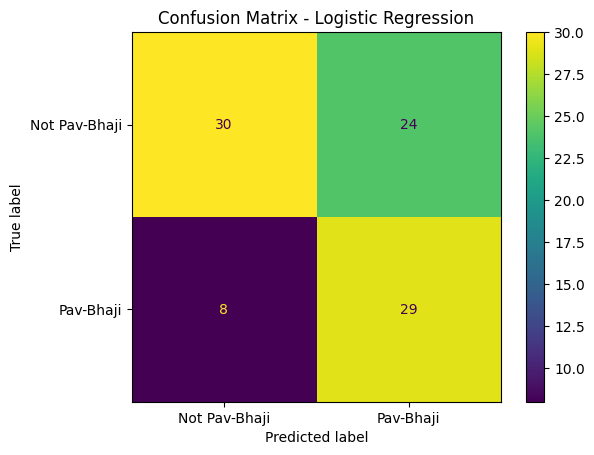

In [22]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Not Pav-Bhaji", "Pav-Bhaji"]
)

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [23]:
import pandas as pd

feature_names = vectorizer.get_feature_names_out()
coefficients = model.coef_[0]

feature_importance = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
})

# Features associated with Pav-Bhaji (class 1)
top_pavbhaji = feature_importance.sort_values(
    "coefficient", ascending=False
).head(20)

# Features associated with Not Pav-Bhaji (class 0)
top_non_pavbhaji = feature_importance.sort_values(
    "coefficient", ascending=True
).head(20)

print("Top features associated with Pav-Bhaji:")
print(top_pavbhaji.to_string(index=False))

print("\n" + "=" * 60)

print("\nTop features associated with Not Pav-Bhaji:")
print(top_non_pavbhaji.to_string(index=False))

Top features associated with Pav-Bhaji:
          feature  coefficient
         pavbhaji     1.392897
        foodlover     1.263011
pavbhaji pavbhaji     0.896553
         foodgasm     0.857568
              pav     0.810478
          monsoon     0.779581
         homemade     0.770799
       vegetables     0.722244
          bhukkad     0.694505
           follow     0.674755
        breakfast     0.670229
       mumbaifood     0.634875
           butter     0.627042
          special     0.614137
     likeforlikes     0.613989
            bhaji     0.610689
  foodphotography     0.609008
           street     0.599633
          buttery     0.599080
      homecooking     0.586930


Top features associated with Not Pav-Bhaji:
          feature  coefficient
           fondue    -0.804215
          vadapav    -0.758577
         bhelpuri    -0.726574
         panipuri    -0.706241
homemade pavbhaji    -0.648929
            pizza    -0.560875
    mumbaidiaries    -0.498232
      foodforli

In [24]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC(
    class_weight="balanced",
    random_state=42
)

svm_model.fit(X_train, y_train)

svm_pred = svm_model.predict(X_test)

print("Linear SVM Performance")
print("=" * 40)

print(f"Accuracy :  {accuracy_score(y_test, svm_pred):.4f}")
print(f"Precision:  {precision_score(y_test, svm_pred):.4f}")
print(f"Recall   :  {recall_score(y_test, svm_pred):.4f}")
print(f"F1-Score :  {f1_score(y_test, svm_pred):.4f}")

print("\nClassification Report:")
print(classification_report(
    y_test,
    svm_pred,
    target_names=["Not Pav-Bhaji", "Pav-Bhaji"]
))

Linear SVM Performance
Accuracy :  0.6044
Precision:  0.5102
Recall   :  0.6757
F1-Score :  0.5814

Classification Report:
               precision    recall  f1-score   support

Not Pav-Bhaji       0.71      0.56      0.62        54
    Pav-Bhaji       0.51      0.68      0.58        37

     accuracy                           0.60        91
    macro avg       0.61      0.62      0.60        91
 weighted avg       0.63      0.60      0.61        91



In [25]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

nb_pred = nb_model.predict(X_test)

print("Naive Bayes Performance")
print("=" * 40)

print(f"Accuracy :  {accuracy_score(y_test, nb_pred):.4f}")
print(f"Precision:  {precision_score(y_test, nb_pred):.4f}")
print(f"Recall   :  {recall_score(y_test, nb_pred):.4f}")
print(f"F1-Score :  {f1_score(y_test, nb_pred):.4f}")

print("\nClassification Report:")
print(classification_report(
    y_test,
    nb_pred,
    target_names=["Not Pav-Bhaji", "Pav-Bhaji"]
))

Naive Bayes Performance
Accuracy :  0.6374
Precision:  0.5370
Recall   :  0.7838
F1-Score :  0.6374

Classification Report:
               precision    recall  f1-score   support

Not Pav-Bhaji       0.78      0.54      0.64        54
    Pav-Bhaji       0.54      0.78      0.64        37

     accuracy                           0.64        91
    macro avg       0.66      0.66      0.64        91
 weighted avg       0.68      0.64      0.64        91



In [26]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate

pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        stop_words="english",
        ngram_range=(1, 2),
        max_features=2000,
        min_df=2
    )),
    ("classifier", LogisticRegression(
        class_weight="balanced",
        random_state=42,
        max_iter=1000
    ))
])

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = cross_validate(
    pipeline,
    df_model["clean_text"],
    df_model["label"],
    cv=cv,
    scoring=["accuracy", "precision", "recall", "f1"]
)

print("5-Fold Cross-Validation Results")
print("=" * 45)

print(f"Accuracy : {cv_results['test_accuracy'].mean():.4f} ± {cv_results['test_accuracy'].std():.4f}")
print(f"Precision: {cv_results['test_precision'].mean():.4f} ± {cv_results['test_precision'].std():.4f}")
print(f"Recall   : {cv_results['test_recall'].mean():.4f} ± {cv_results['test_recall'].std():.4f}")
print(f"F1-Score : {cv_results['test_f1'].mean():.4f} ± {cv_results['test_f1'].std():.4f}")

5-Fold Cross-Validation Results
Accuracy : 0.6813 ± 0.0444
Precision: 0.5815 ± 0.0433
Recall   : 0.7646 ± 0.0650
F1-Score : 0.6598 ± 0.0475


In [27]:
caption_train, caption_test, y_train_cap, y_test_cap = train_test_split(
    df_model["caption_text"].apply(clean_text),
    df_model["label"],
    test_size=0.20,
    random_state=42,
    stratify=df_model["label"]
)

caption_vectorizer = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    max_features=2000,
    min_df=2
)

X_train_cap = caption_vectorizer.fit_transform(caption_train)
X_test_cap = caption_vectorizer.transform(caption_test)

caption_model = LogisticRegression(
    class_weight="balanced",
    random_state=42,
    max_iter=1000
)

caption_model.fit(X_train_cap, y_train_cap)

caption_pred = caption_model.predict(X_test_cap)

print("Caption-only Logistic Regression")
print("=" * 45)
print(f"Accuracy :  {accuracy_score(y_test_cap, caption_pred):.4f}")
print(f"Precision:  {precision_score(y_test_cap, caption_pred):.4f}")
print(f"Recall   :  {recall_score(y_test_cap, caption_pred):.4f}")
print(f"F1-Score :  {f1_score(y_test_cap, caption_pred):.4f}")

Caption-only Logistic Regression
Accuracy :  0.6374
Precision:  0.5435
Recall   :  0.6757
F1-Score :  0.6024


In [28]:
def remove_target_words(text):
    words_to_remove = {"pavbhaji", "pav", "bhaji"}

    words = str(text).split()

    filtered_words = [
        word for word in words
        if word not in words_to_remove
    ]

    return " ".join(filtered_words)


df_model["text_without_target_words"] = (
    df_model["clean_text"].apply(remove_target_words)
)

print(df_model[
    ["clean_text", "text_without_target_words"]
].head(3).to_string())

In [29]:
from sklearn.pipeline import Pipeline

final_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        stop_words="english",
        ngram_range=(1, 2),
        max_features=2000,
        min_df=2
    )),
    ("classifier", LogisticRegression(
        class_weight="balanced",
        random_state=42,
        max_iter=1000
    ))
])

final_pipeline.fit(X_train_text, y_train)

final_predictions = final_pipeline.predict(X_test_text)

print("Final pipeline trained successfully!")
print(f"Test Accuracy: {accuracy_score(y_test, final_predictions) * 100:.2f}%")
print(f"Test F1-Score: {f1_score(y_test, final_predictions):.4f}")

Final pipeline trained successfully!
Test Accuracy: 64.84%
Test F1-Score: 0.6444


Confusion Matrix:
[[30 24]
 [ 8 29]]


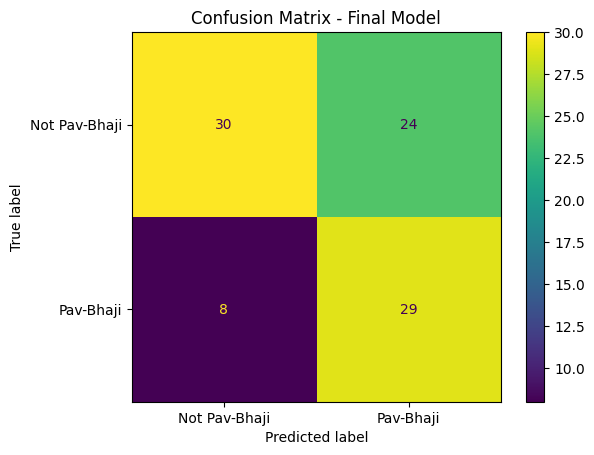

In [30]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, final_predictions)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Pav-Bhaji", "Pav-Bhaji"]
)

disp.plot()
plt.title("Confusion Matrix - Final Model")
plt.show()

In [31]:
# Get TF-IDF feature names and Logistic Regression coefficients

tfidf = final_pipeline.named_steps["tfidf"]
classifier = final_pipeline.named_steps["classifier"]

feature_names = tfidf.get_feature_names_out()
coefficients = classifier.coef_[0]

# Most associated with Pav-Bhaji
positive_features = sorted(
    zip(feature_names, coefficients),
    key=lambda x: x[1],
    reverse=True
)[:20]

# Most associated with Not Pav-Bhaji
negative_features = sorted(
    zip(feature_names, coefficients),
    key=lambda x: x[1]
)[:20]

print("Top features associated with Pav-Bhaji:")
for feature, coef in positive_features:
    print(f"{feature:30s} {coef:.4f}")

print("\nTop features associated with Not Pav-Bhaji:")
for feature, coef in negative_features:
    print(f"{feature:30s} {coef:.4f}")

Top features associated with Pav-Bhaji:
pavbhaji                       1.3929
foodlover                      1.2630
pavbhaji pavbhaji              0.8966
foodgasm                       0.8576
pav                            0.8105
monsoon                        0.7796
homemade                       0.7708
vegetables                     0.7222
bhukkad                        0.6945
follow                         0.6748
breakfast                      0.6702
mumbaifood                     0.6349
butter                         0.6270
special                        0.6141
likeforlikes                   0.6140
bhaji                          0.6107
foodphotography                0.6090
street                         0.5996
buttery                        0.5991
homecooking                    0.5869

Top features associated with Not Pav-Bhaji:
fondue                         -0.8042
vadapav                        -0.7586
bhelpuri                       -0.7266
panipuri                       -0.7062

In [32]:
def predict_pav_bhaji(caption, tags=""):
    """
    Predict whether an Instagram post is Pav-Bhaji
    using caption and hashtag metadata.

    Returns:
        1 -> Pav-Bhaji
        0 -> Not Pav-Bhaji
    """

    # Combine caption and tags
    text = str(caption) + " " + str(tags)

    # Apply the same preprocessing used during training
    text = clean_text(text)

    # Predict
    prediction = final_pipeline.predict([text])[0]

    # Get probability
    probability = final_pipeline.predict_proba([text])[0]

    if prediction == 1:
        label = "Pav-Bhaji"
    else:
        label = "Not Pav-Bhaji"

    return label, probability[prediction]

In [33]:
caption = "Hot homemade pav bhaji with butter and vegetables"
tags = "pavbhaji homemade food mumbai food"

prediction, confidence = predict_pav_bhaji(caption, tags)

print("Prediction:", prediction)
print(f"Confidence: {confidence * 100:.2f}%")

Prediction: Pav-Bhaji
Confidence: 70.99%


In [34]:
caption = "Delicious chicken tikka with spicy sauce"
tags = "chicken tikka chicken food foodphotography"

prediction, confidence = predict_pav_bhaji(caption, tags)

print("Prediction:", prediction)
print(f"Confidence: {confidence * 100:.2f}%")

Prediction: Not Pav-Bhaji
Confidence: 63.92%
